In [2]:
#TASK 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (adjust path if needed)
df = pd.read_csv('household_power_consumption.txt', sep=';',
                 parse_dates={'datetime': ['Date', 'Time']},
                 dayfirst=True, low_memory=False)

# Convert columns to numeric (handle ? as NaN)
df.replace('?', np.nan, inplace=True)
df['Global_active_power'] = df['Global_active_power'].astype(float)
df['Global_reactive_power'] = df['Global_reactive_power'].astype(float)
df['Voltage'] = df['Voltage'].astype(float)
df['Global_intensity'] = df['Global_intensity'].astype(float)
df['Sub_metering_1'] = df['Sub_metering_1'].astype(float)
df['Sub_metering_2'] = df['Sub_metering_2'].astype(float)
df['Sub_metering_3'] = df['Sub_metering_3'].astype(float)

# Set datetime as index
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(df.head())
print(df.shape)

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

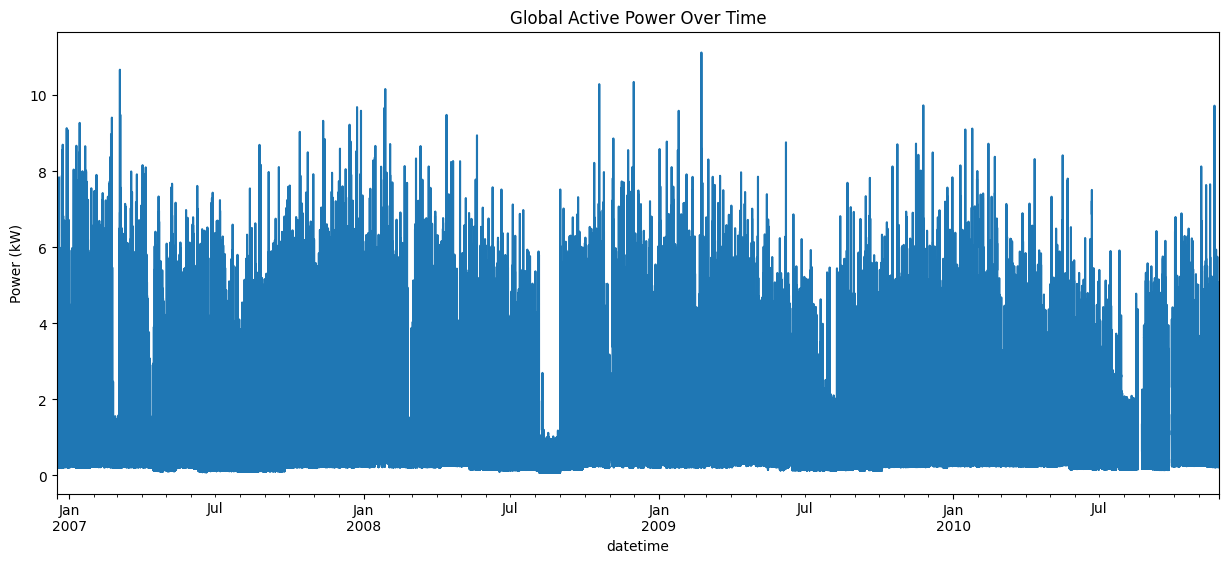

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


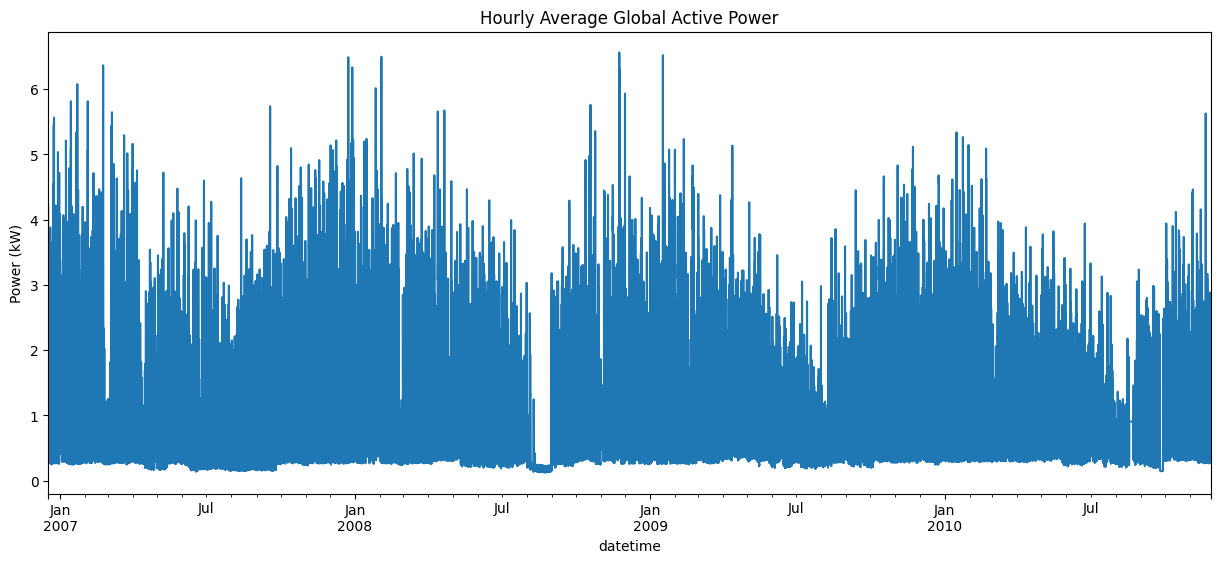

In [4]:
# 1. Plot time-series of Global_active_power
plt.figure(figsize=(15,6))
df['Global_active_power'].plot()
plt.title('Global Active Power Over Time')
plt.ylabel('Power (kW)')
plt.show()

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing values using forward fill (common for time series)
df['Global_active_power'].fillna(method='ffill', inplace=True)

# Resample to hourly (since data is minute-level)
hourly = df['Global_active_power'].resample('H').mean()

plt.figure(figsize=(15,6))
hourly.plot()
plt.title('Hourly Average Global Active Power')
plt.ylabel('Power (kW)')
plt.show()

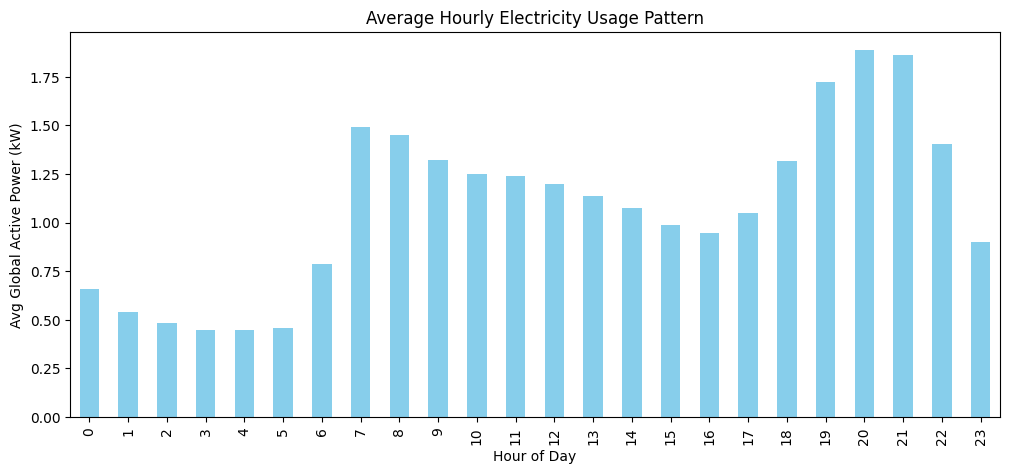

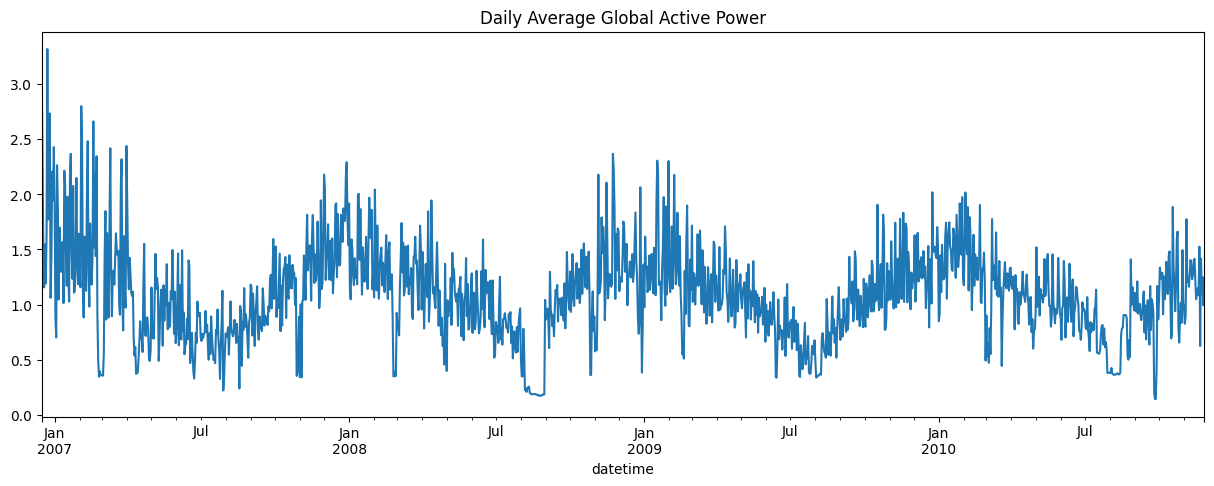

Peak hours (top 5):
datetime
20    1.886522
21    1.864519
19    1.721268
7     1.490076
8     1.449551
Name: Global_active_power, dtype: float64

Low usage hours (bottom 5):
datetime
4    0.446164
3    0.447379
5    0.455703
2    0.482724
1    0.540739
Name: Global_active_power, dtype: float64


In [5]:
# 2. Daily and Hourly Patterns
hourly_df = df.resample('H').mean()

# Hourly pattern (average across all days)
hourly_pattern = hourly_df.groupby(hourly_df.index.hour)['Global_active_power'].mean()

plt.figure(figsize=(12,5))
hourly_pattern.plot(kind='bar', color='skyblue')
plt.title('Average Hourly Electricity Usage Pattern')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Global Active Power (kW)')
plt.show()

# Daily pattern
daily_df = df.resample('D').mean()
plt.figure(figsize=(15,5))
daily_df['Global_active_power'].plot()
plt.title('Daily Average Global Active Power')
plt.show()

# High and low usage periods
print("Peak hours (top 5):")
print(hourly_pattern.nlargest(5))
print("\nLow usage hours (bottom 5):")
print(hourly_pattern.nsmallest(5))

In [6]:
#TASK 2

In [7]:
# Prepare data for LSTM
data = hourly_df['Global_active_power'].values
data = data.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences (use past 24 hours to predict next hour)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 24
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Train-test split (last 10% as test)
split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)

(31108, 24, 1) (31108, 1)


In [8]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0155 - val_loss: 0.0068
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0092 - val_loss: 0.0064
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0090 - val_loss: 0.0065
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0086 - val_loss: 0.0063
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0086 - val_loss: 0.0065
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0087 - val_loss: 0.0063
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0085 - val_loss: 0.0064
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0087 - val_loss: 0.0065
Epoch 9/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0085 - val_loss: 0.0063
Epoch 10/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0085 - val_loss: 0.0062
Epoch 11/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0085 - val_loss: 0.0063
Epoch 12/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/ste

In [9]:
# Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# Evaluation
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print(f"MAE: {mae:.4f} kW")
print(f"RMSE: {rmse:.4f} kW")

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MAE: 0.3615 kW
RMSE: 0.4897 kW


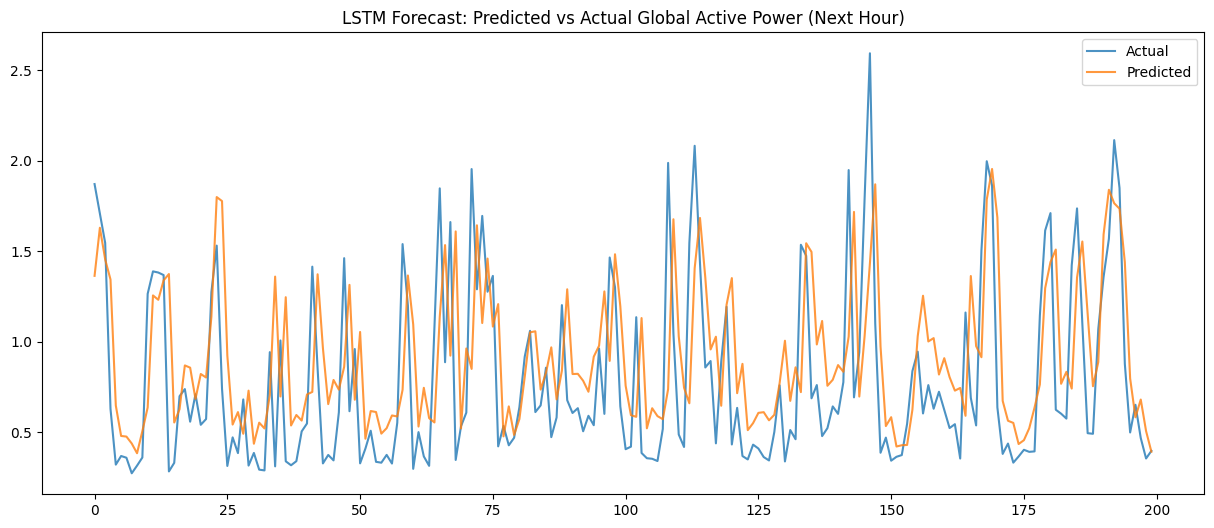

In [10]:
# Plot Predicted vs Actual
plt.figure(figsize=(15,6))
plt.plot(y_test_actual[:200], label='Actual', alpha=0.8)
plt.plot(y_pred[:200], label='Predicted', alpha=0.8)
plt.title('LSTM Forecast: Predicted vs Actual Global Active Power (Next Hour)')
plt.legend()
plt.show()

In [11]:
#TASK 3

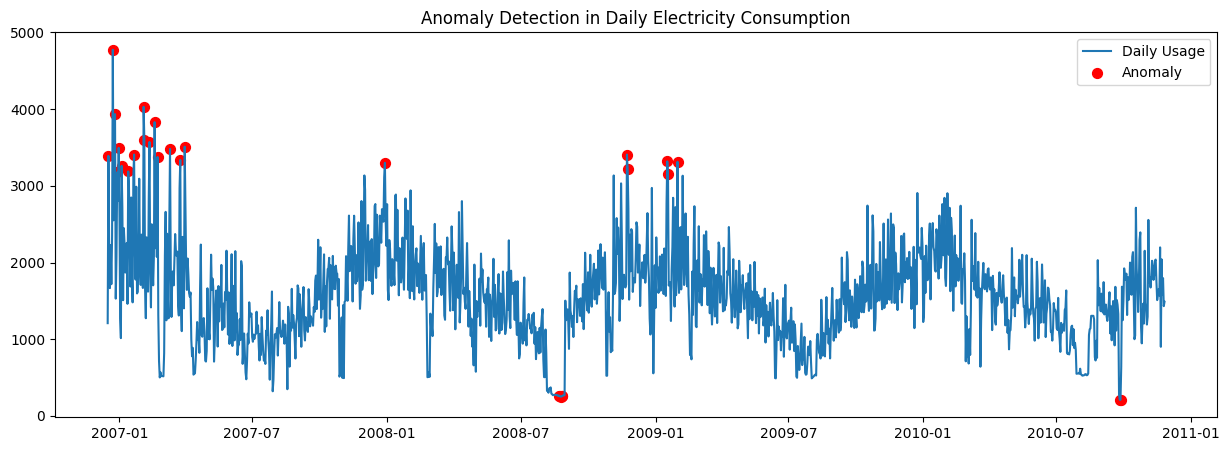

In [12]:
# 1. Anomaly Detection using Isolation Forest
from sklearn.ensemble import IsolationForest

daily_consumption = df['Global_active_power'].resample('D').sum().dropna()
daily_features = daily_consumption.values.reshape(-1, 1)

iso_forest = IsolationForest(contamination=0.02, random_state=42)
anomalies = iso_forest.fit_predict(daily_features)
anomalies = np.where(anomalies == -1)[0]

plt.figure(figsize=(15,5))
plt.plot(daily_consumption.index, daily_consumption.values, label='Daily Usage')
plt.scatter(daily_consumption.index[anomalies], daily_consumption.values[anomalies],
            color='red', label='Anomaly', s=50)
plt.title('Anomaly Detection in Daily Electricity Consumption')
plt.legend()
plt.show()

In [13]:
# 2. Clustering on Daily Profiles (using hourly pattern of a day)
def get_daily_profile(date):
    day_data = hourly_df[hourly_df.index.date == date]
    if len(day_data) == 24:
        return day_data['Global_active_power'].values
    else:
        return None

daily_profiles = []
dates = []

for date in pd.date_range('2007-01-01', '2010-12-31'):
    profile = get_daily_profile(date.date())
    if profile is not None:
        daily_profiles.append(profile)
        dates.append(date)

daily_profiles = np.array(daily_profiles)
print("Number of complete daily profiles:", daily_profiles.shape[0])

Number of complete daily profiles: 1425


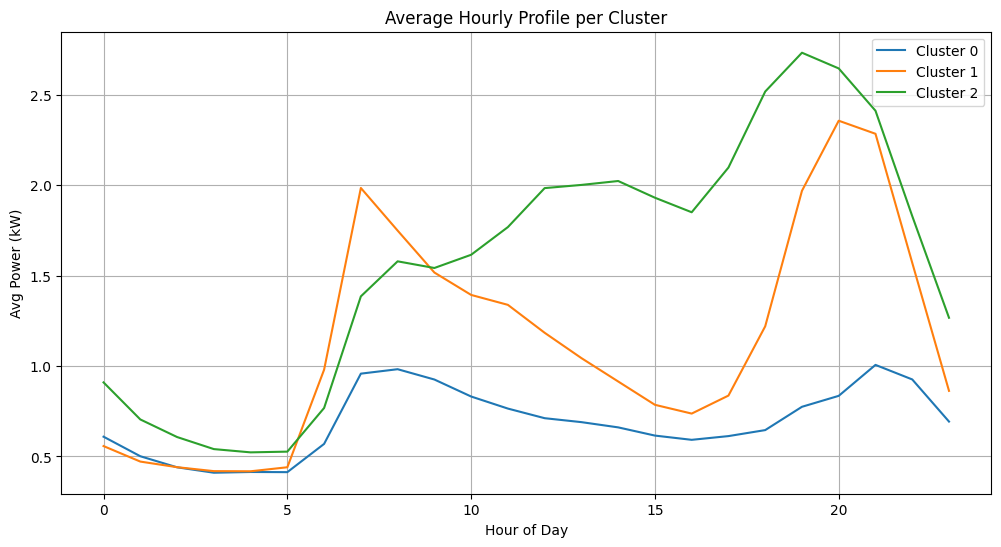

In [14]:
# K-Means Clustering on Daily Profiles
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(daily_profiles)

# Add cluster labels
clustered_df = pd.DataFrame(daily_profiles)
clustered_df['cluster'] = clusters
clustered_df['date'] = dates

# Visualize clusters
plt.figure(figsize=(12,6))
for i in range(3):
    plt.plot(clustered_df[clustered_df['cluster']==i].iloc[:, :24].mean(), label=f'Cluster {i}')
plt.title('Average Hourly Profile per Cluster')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Cluster Characteristics
cluster_means = clustered_df.groupby('cluster').mean().iloc[:, :24].mean(axis=1)
print("Cluster Daily Average Usage:")
for i in range(3):
    print(f"Cluster {i}: {cluster_means[i]:.2f} kW →", end=" ")
    if i == cluster_means.idxmin():
        print("Low Usage Days (e.g., holidays, absences)")
    elif i == cluster_means.idxmax():
        print("High Usage Days (e.g., cold winter days, heavy appliance use)")
    else:
        print("Medium/Normal Usage Days")

Cluster Daily Average Usage:
Cluster 0: 0.69 kW → Low Usage Days (e.g., holidays, absences)
Cluster 1: 1.14 kW → Medium/Normal Usage Days
Cluster 2: 1.57 kW → High Usage Days (e.g., cold winter days, heavy appliance use)


In [16]:
#TASK 4

In [17]:
# Use last 100 predictions as example
recent_predictions = y_pred[-100:]

def categorize_usage(power_kw):
    if power_kw < 0.8:
        category = "Low Usage"
        suggestion = "Great job! You're conserving energy. Consider maintaining this pattern."
    elif power_kw < 2.0:
        category = "Medium Usage"
        suggestion = "Normal usage. Try turning off unused lights and appliances to save more."
    else:
        category = "High Usage"
        suggestion = "High consumption detected! Consider using energy-efficient devices or reducing AC/heating."
    return category, suggestion

# Example output
example_power = recent_predictions[-1][0]  # latest prediction
category, suggestion = categorize_usage(example_power)

print("=== Simple AI Consumption Advisor ===")
print(f"Predicted Next-Hour Global Active Power: {example_power:.3f} kW")
print(f"Usage Category: {category}")
print(f"Suggestion: {suggestion}")

=== Simple AI Consumption Advisor ===
Predicted Next-Hour Global Active Power: 1.112 kW
Usage Category: Medium Usage
Suggestion: Normal usage. Try turning off unused lights and appliances to save more.
